In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_source/student_habits_performance.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
# check how many and what values exist
print(df['parental_education_level'].value_counts())
print(df['parental_education_level'].isna().sum())  # 91

# fill with mode — most common education level
df['parental_education_level'] = df['parental_education_level'].fillna(
    df['parental_education_level'].mode()[0]
)

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
91


In [5]:
cat_cols = ['gender', 'part_time_job', 'diet_quality',
            'internet_quality', 'extracurricular_participation',
            'parental_education_level']

for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")


gender: ['Female' 'Male' 'Other']

part_time_job: ['No' 'Yes']

diet_quality: ['Fair' 'Good' 'Poor']

internet_quality: ['Average' 'Poor' 'Good']

extracurricular_participation: ['Yes' 'No']

parental_education_level: ['Master' 'High School' 'Bachelor']


/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/1895104166.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='exam_score',
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/1895104166.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='part_time_job', y='exam_score',
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/1895104166.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parental_education_level', y='exam_score',


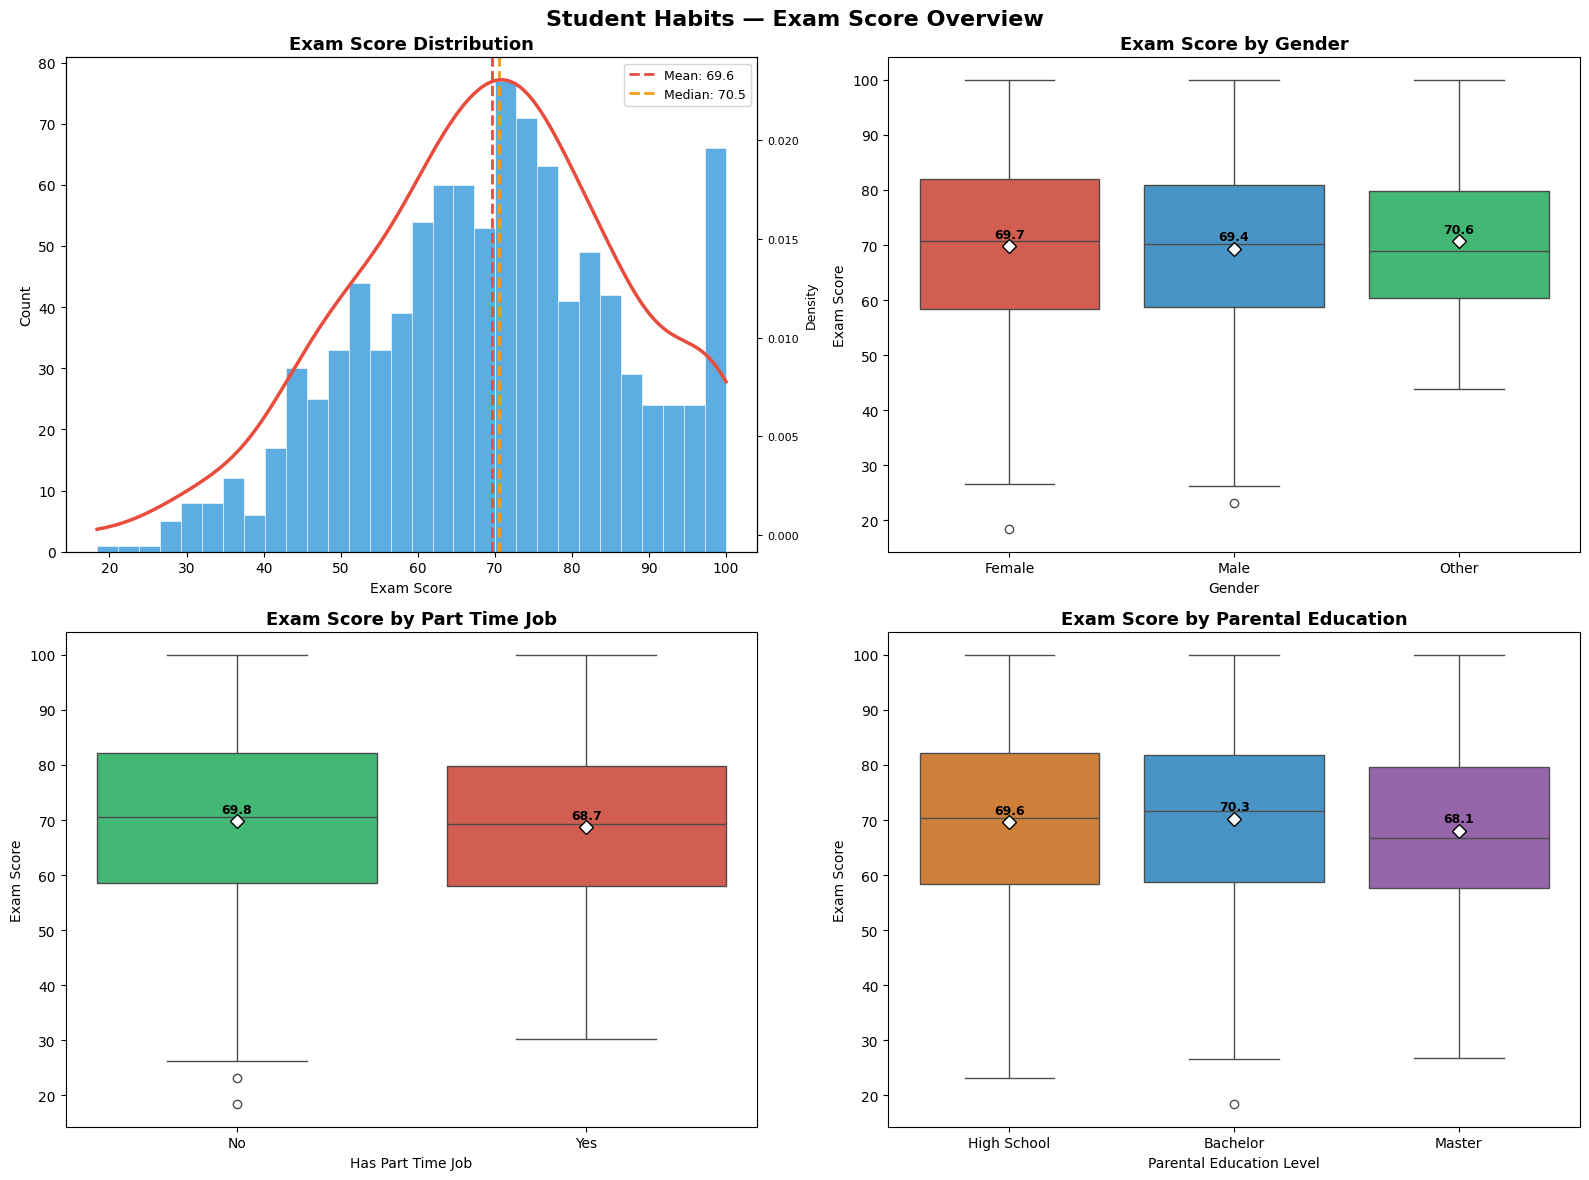

In [6]:
import os
os.makedirs('visualizations', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# color palette
palette_gender = {'Female': '#e74c3c', 'Male': '#3498db', 'Other': '#2ecc71'}

# ── 1. Exam score distribution ─────────────────────────────────
axes[0].hist(df['exam_score'], bins=30, color='#3498db',
             edgecolor='white', linewidth=0.5, alpha=0.8)

# KDE overlay
from scipy.stats import gaussian_kde
kde = gaussian_kde(df['exam_score'], bw_method=0.3)
x = np.linspace(df['exam_score'].min(), df['exam_score'].max(), 300)
ax2 = axes[0].twinx()
ax2.plot(x, kde(x), color='#e74c3c', linewidth=2.5, label='KDE')
ax2.set_ylabel('Density', fontsize=9)
ax2.tick_params(axis='y', labelsize=8)

axes[0].axvline(df['exam_score'].mean(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean: {df["exam_score"].mean():.1f}')
axes[0].axvline(df['exam_score'].median(), color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Median: {df["exam_score"].median():.1f}')
axes[0].set_title('Exam Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# ── 2. Exam score by gender ────────────────────────────────────
sns.boxplot(data=df, x='gender', y='exam_score',
            palette=palette_gender,
            order=['Female', 'Male', 'Other'],
            ax=axes[1])

# add mean markers
for j, gender in enumerate(['Female', 'Male', 'Other']):
    mean_val = df[df['gender'] == gender]['exam_score'].mean()
    axes[1].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[1].text(j, mean_val + 1.5, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Exam Score by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Exam Score')

# ── 3. Exam score by part time job ────────────────────────────
sns.boxplot(data=df, x='part_time_job', y='exam_score',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
            ax=axes[2])

for j, job in enumerate(['No', 'Yes']):
    mean_val = df[df['part_time_job'] == job]['exam_score'].mean()
    axes[2].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[2].text(j, mean_val + 1.5, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[2].set_title('Exam Score by Part Time Job',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Has Part Time Job')
axes[2].set_ylabel('Exam Score')

# ── 4. Exam score by parental education ───────────────────────
order = ['High School', 'Bachelor', 'Master']
sns.boxplot(data=df, x='parental_education_level', y='exam_score',
            palette=['#e67e22', '#3498db', '#9b59b6'],
            order=order, ax=axes[3])

for j, edu in enumerate(order):
    mean_val = df[df['parental_education_level'] == edu]['exam_score'].mean()
    axes[3].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[3].text(j, mean_val + 1.5, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[3].set_title('Exam Score by Parental Education',
                  fontsize=13, fontweight='bold')
axes[3].set_xlabel('Parental Education Level')
axes[3].set_ylabel('Exam Score')

fig.suptitle('Student Habits — Exam Score Overview',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/exam_score_overview.png', dpi=150)
plt.show()

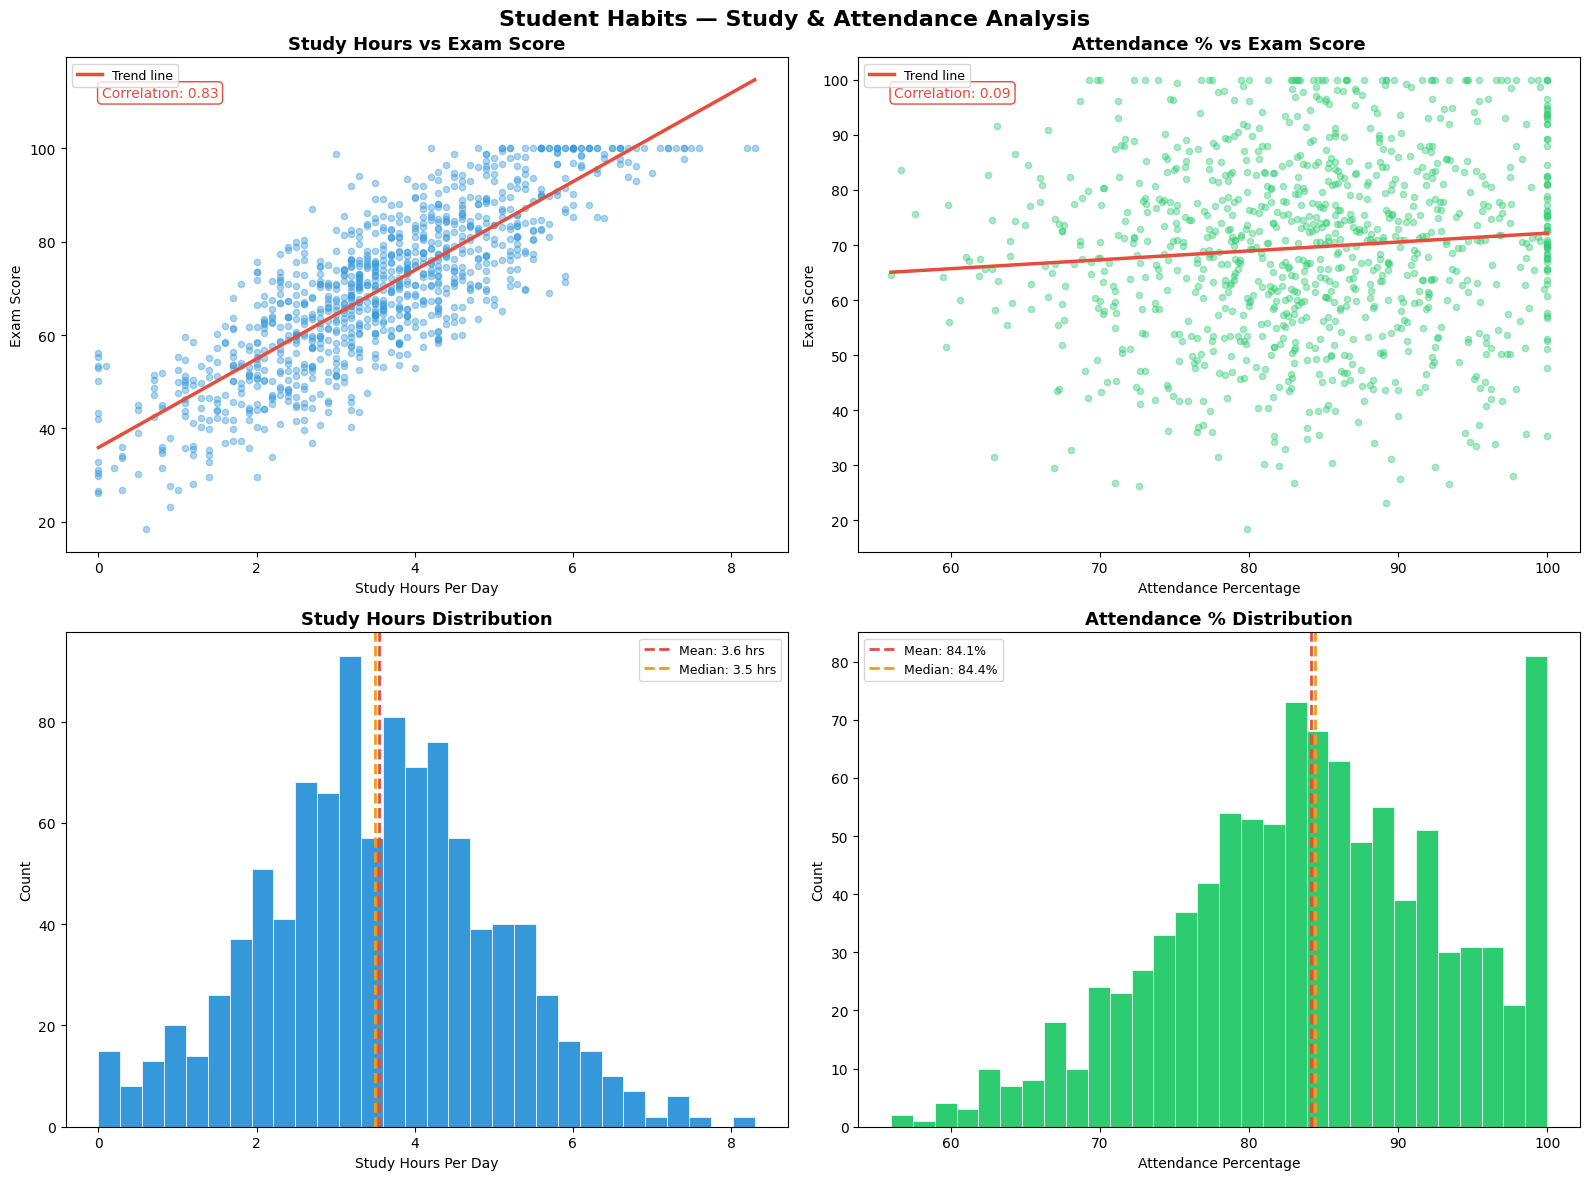

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# ── 5. Study hours vs exam score ──────────────────────────────
axes[0].scatter(df['study_hours_per_day'], df['exam_score'],
                alpha=0.4, s=20, color='#3498db')

z = np.polyfit(df['study_hours_per_day'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['study_hours_per_day'].min(),
                     df['study_hours_per_day'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#e74c3c',
             linewidth=2.5, label=f'Trend line')

axes[0].set_title('Study Hours vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Study Hours Per Day')
axes[0].set_ylabel('Exam Score')
axes[0].legend(fontsize=9)

corr = df['study_hours_per_day'].corr(df['exam_score'])
axes[0].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[0].transAxes,
             fontsize=10, color='#e74c3c',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#e74c3c'))

# ── 6. Attendance vs exam score ────────────────────────────────
axes[1].scatter(df['attendance_percentage'], df['exam_score'],
                alpha=0.4, s=20, color='#2ecc71')

z = np.polyfit(df['attendance_percentage'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['attendance_percentage'].min(),
                     df['attendance_percentage'].max(), 100)
axes[1].plot(x_line, p(x_line), color='#e74c3c',
             linewidth=2.5, label='Trend line')

axes[1].set_title('Attendance % vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attendance Percentage')
axes[1].set_ylabel('Exam Score')
axes[1].legend(fontsize=9)

corr = df['attendance_percentage'].corr(df['exam_score'])
axes[1].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[1].transAxes,
             fontsize=10, color='#e74c3c',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#e74c3c'))

# ── 7. Study hours distribution ────────────────────────────────
axes[2].hist(df['study_hours_per_day'], bins=30,
             color='#3498db', edgecolor='white', linewidth=0.5)
axes[2].axvline(df['study_hours_per_day'].mean(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean: {df["study_hours_per_day"].mean():.1f} hrs')
axes[2].axvline(df['study_hours_per_day'].median(), color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Median: {df["study_hours_per_day"].median():.1f} hrs')
axes[2].set_title('Study Hours Distribution',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Study Hours Per Day')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

# ── 8. Attendance distribution ─────────────────────────────────
axes[3].hist(df['attendance_percentage'], bins=30,
             color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[3].axvline(df['attendance_percentage'].mean(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean: {df["attendance_percentage"].mean():.1f}%')
axes[3].axvline(df['attendance_percentage'].median(), color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Median: {df["attendance_percentage"].median():.1f}%')
axes[3].set_title('Attendance % Distribution',
                  fontsize=13, fontweight='bold')
axes[3].set_xlabel('Attendance Percentage')
axes[3].set_ylabel('Count')
axes[3].legend(fontsize=9)

fig.suptitle('Student Habits — Study & Attendance Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/study_attendance_analysis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/2227969481.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='exam_tier', y='total_screen_time',


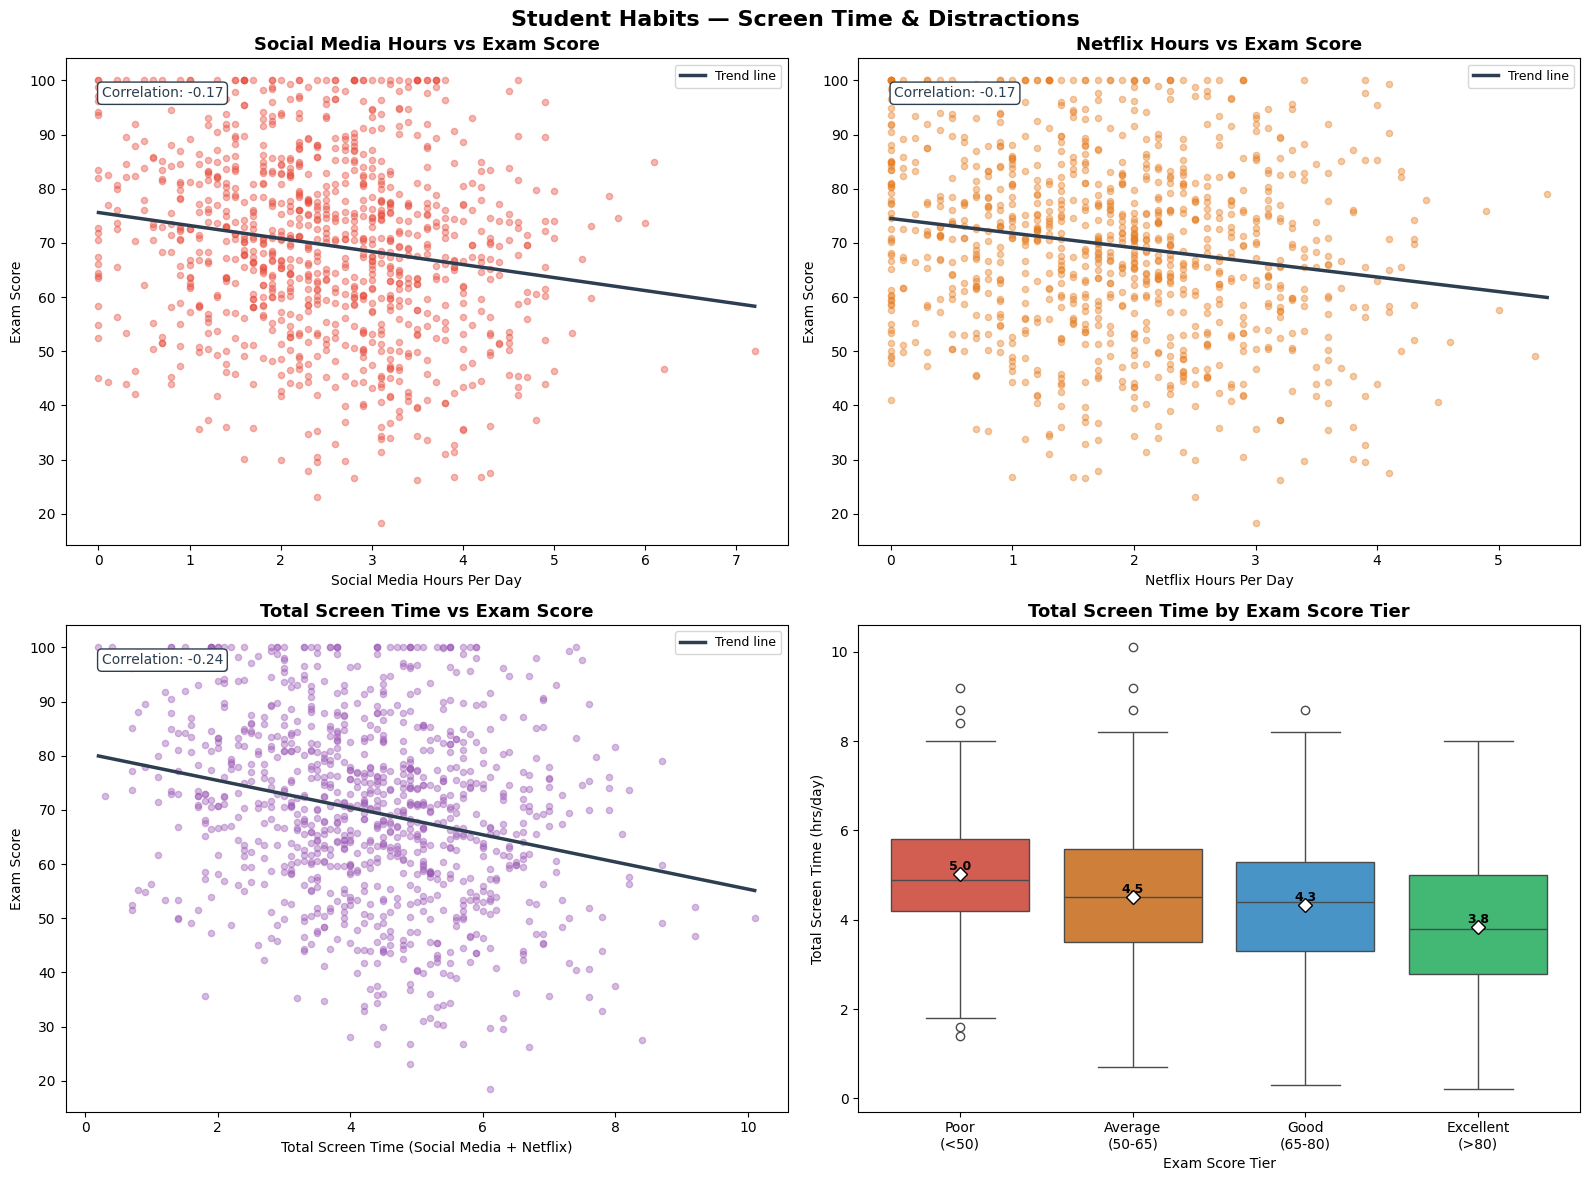

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# ── 9. Social media hours vs exam score ───────────────────────
axes[0].scatter(df['social_media_hours'], df['exam_score'],
                alpha=0.4, s=20, color='#e74c3c')

z = np.polyfit(df['social_media_hours'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['social_media_hours'].min(),
                     df['social_media_hours'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#2c3e50',
             linewidth=2.5, label='Trend line')

axes[0].set_title('Social Media Hours vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Social Media Hours Per Day')
axes[0].set_ylabel('Exam Score')
axes[0].legend(fontsize=9)

corr = df['social_media_hours'].corr(df['exam_score'])
axes[0].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[0].transAxes,
             fontsize=10, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#2c3e50'))

# ── 10. Netflix hours vs exam score ───────────────────────────
axes[1].scatter(df['netflix_hours'], df['exam_score'],
                alpha=0.4, s=20, color='#e67e22')

z = np.polyfit(df['netflix_hours'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['netflix_hours'].min(),
                     df['netflix_hours'].max(), 100)
axes[1].plot(x_line, p(x_line), color='#2c3e50',
             linewidth=2.5, label='Trend line')

axes[1].set_title('Netflix Hours vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Netflix Hours Per Day')
axes[1].set_ylabel('Exam Score')
axes[1].legend(fontsize=9)

corr = df['netflix_hours'].corr(df['exam_score'])
axes[1].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[1].transAxes,
             fontsize=10, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#2c3e50'))

# ── 11. Combined screen time vs exam score ────────────────────
df['total_screen_time'] = df['social_media_hours'] + df['netflix_hours']

axes[2].scatter(df['total_screen_time'], df['exam_score'],
                alpha=0.4, s=20, color='#9b59b6')

z = np.polyfit(df['total_screen_time'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['total_screen_time'].min(),
                     df['total_screen_time'].max(), 100)
axes[2].plot(x_line, p(x_line), color='#2c3e50',
             linewidth=2.5, label='Trend line')

axes[2].set_title('Total Screen Time vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Total Screen Time (Social Media + Netflix)')
axes[2].set_ylabel('Exam Score')
axes[2].legend(fontsize=9)

corr = df['total_screen_time'].corr(df['exam_score'])
axes[2].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[2].transAxes,
             fontsize=10, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#2c3e50'))

# ── 12. Screen time by exam score tier ────────────────────────
# create exam score tier
df['exam_tier'] = pd.cut(df['exam_score'],
                          bins=[0, 50, 65, 80, 100],
                          labels=['Poor\n(<50)', 'Average\n(50-65)',
                                  'Good\n(65-80)', 'Excellent\n(>80)'])

sns.boxplot(data=df, x='exam_tier', y='total_screen_time',
            palette=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],
            ax=axes[3])

axes[3].set_title('Total Screen Time by Exam Score Tier',
                  fontsize=13, fontweight='bold')
axes[3].set_xlabel('Exam Score Tier')
axes[3].set_ylabel('Total Screen Time (hrs/day)')

# add mean markers
for j, tier in enumerate(['Poor\n(<50)', 'Average\n(50-65)',
                           'Good\n(65-80)', 'Excellent\n(>80)']):
    mean_val = df[df['exam_tier'] == tier]['total_screen_time'].mean()
    axes[3].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[3].text(j, mean_val + 0.1, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Student Habits — Screen Time & Distractions',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/screen_time_analysis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/3396634516.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diet_quality', y='exam_score',


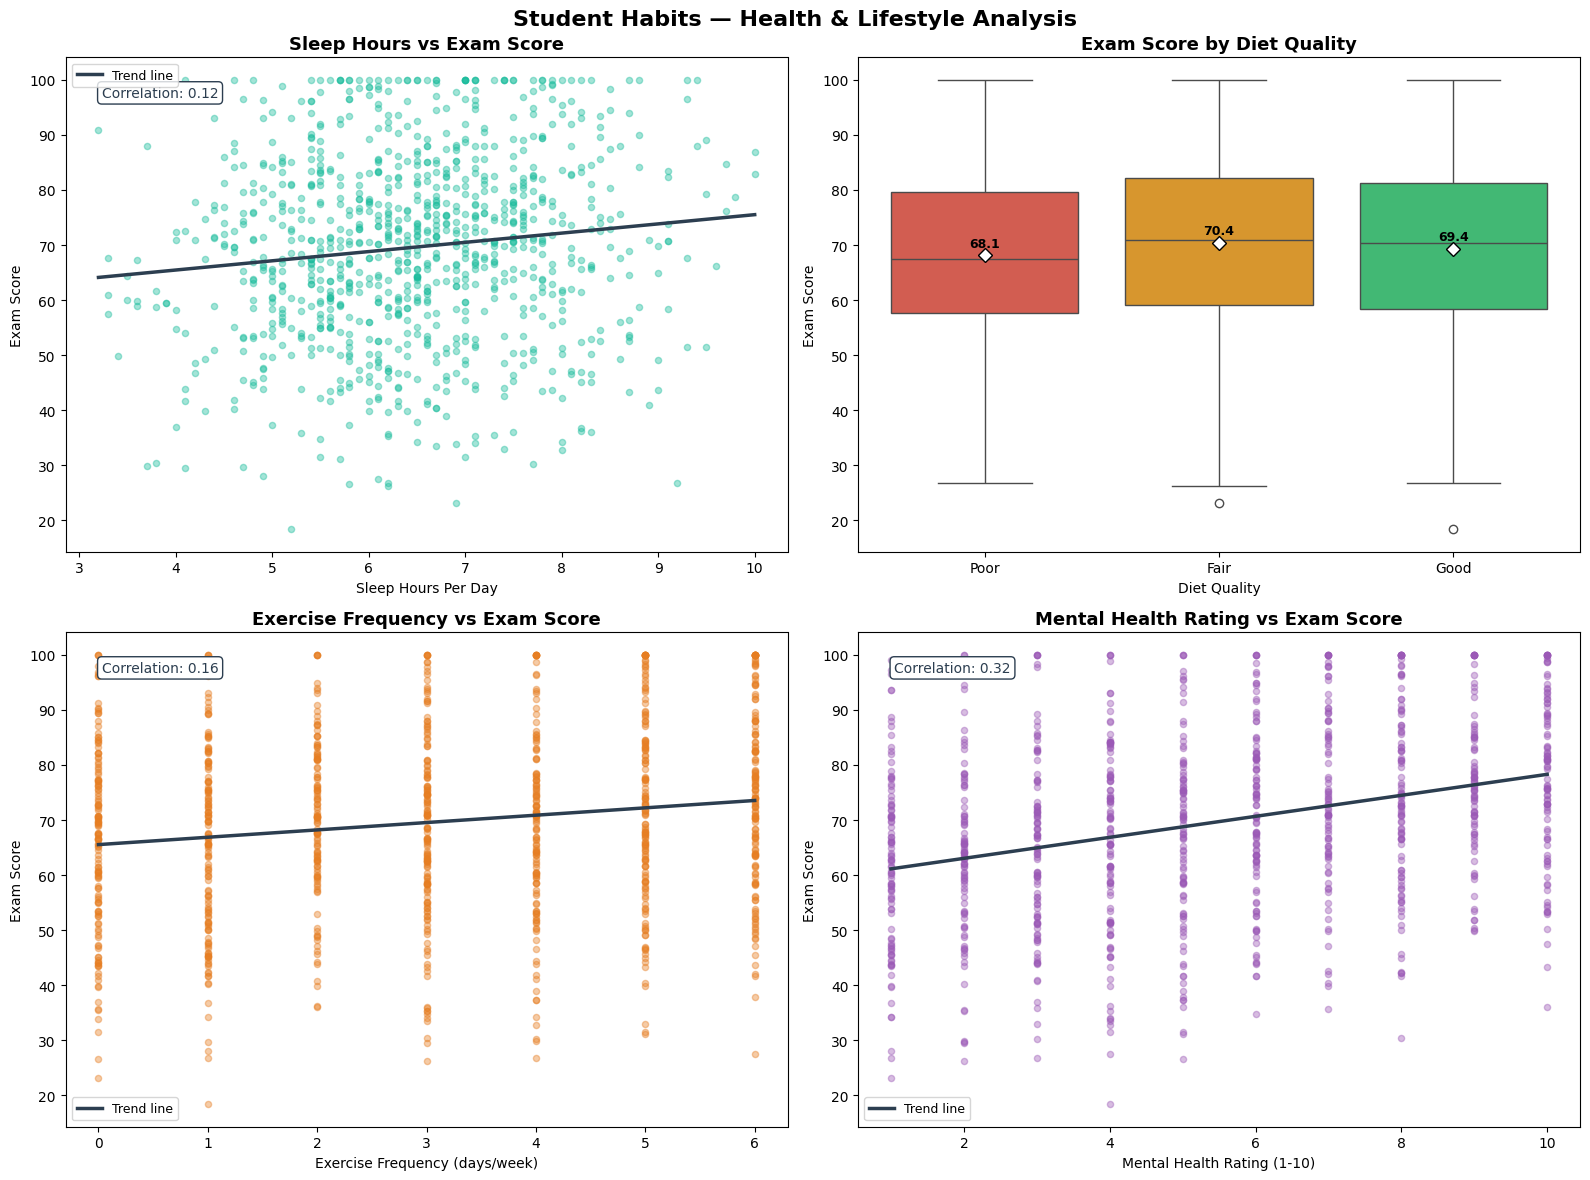

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# ── 13. Sleep hours vs exam score ─────────────────────────────
axes[0].scatter(df['sleep_hours'], df['exam_score'],
                alpha=0.4, s=20, color='#1abc9c')

z = np.polyfit(df['sleep_hours'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sleep_hours'].min(),
                     df['sleep_hours'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#2c3e50',
             linewidth=2.5, label='Trend line')

axes[0].set_title('Sleep Hours vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sleep Hours Per Day')
axes[0].set_ylabel('Exam Score')
axes[0].legend(fontsize=9)

corr = df['sleep_hours'].corr(df['exam_score'])
axes[0].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[0].transAxes,
             fontsize=10, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#2c3e50'))

# ── 14. Exam score by diet quality ────────────────────────────
order = ['Poor', 'Fair', 'Good']
sns.boxplot(data=df, x='diet_quality', y='exam_score',
            palette={'Poor': '#e74c3c',
                     'Fair': '#f39c12',
                     'Good': '#2ecc71'},
            order=order, ax=axes[1])

for j, diet in enumerate(order):
    mean_val = df[df['diet_quality'] == diet]['exam_score'].mean()
    axes[1].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[1].text(j, mean_val + 1.5, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Exam Score by Diet Quality',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diet Quality')
axes[1].set_ylabel('Exam Score')

# ── 15. Exercise frequency vs exam score ──────────────────────
axes[2].scatter(df['exercise_frequency'], df['exam_score'],
                alpha=0.4, s=20, color='#e67e22')

z = np.polyfit(df['exercise_frequency'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['exercise_frequency'].min(),
                     df['exercise_frequency'].max(), 100)
axes[2].plot(x_line, p(x_line), color='#2c3e50',
             linewidth=2.5, label='Trend line')

axes[2].set_title('Exercise Frequency vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Exercise Frequency (days/week)')
axes[2].set_ylabel('Exam Score')
axes[2].legend(fontsize=9)

corr = df['exercise_frequency'].corr(df['exam_score'])
axes[2].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[2].transAxes,
             fontsize=10, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#2c3e50'))

# ── 16. Mental health rating vs exam score ────────────────────
axes[3].scatter(df['mental_health_rating'], df['exam_score'],
                alpha=0.4, s=20, color='#9b59b6')

z = np.polyfit(df['mental_health_rating'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['mental_health_rating'].min(),
                     df['mental_health_rating'].max(), 100)
axes[3].plot(x_line, p(x_line), color='#2c3e50',
             linewidth=2.5, label='Trend line')

axes[3].set_title('Mental Health Rating vs Exam Score',
                  fontsize=13, fontweight='bold')
axes[3].set_xlabel('Mental Health Rating (1-10)')
axes[3].set_ylabel('Exam Score')
axes[3].legend(fontsize=9)

corr = df['mental_health_rating'].corr(df['exam_score'])
axes[3].text(0.05, 0.92, f'Correlation: {corr:.2f}',
             transform=axes[3].transAxes,
             fontsize=10, color='#2c3e50',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor='#2c3e50'))

fig.suptitle('Student Habits — Health & Lifestyle Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/health_lifestyle_analysis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/2907674837.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='internet_quality', y='exam_score',
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_1405/2907674837.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='extracurricular_participation',


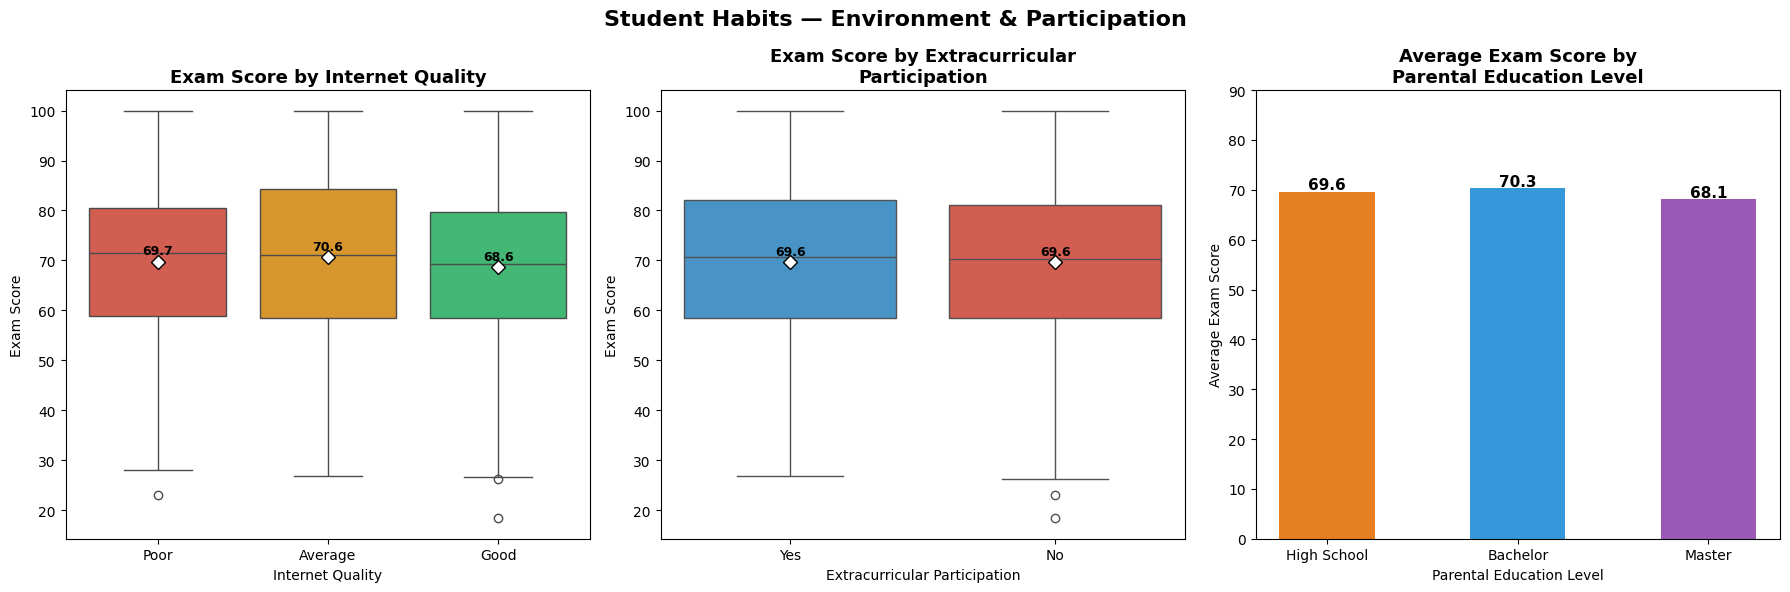

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 17. Exam score by internet quality ────────────────────────
order = ['Poor', 'Average', 'Good']
sns.boxplot(data=df, x='internet_quality', y='exam_score',
            palette={'Poor': '#e74c3c',
                     'Average': '#f39c12',
                     'Good': '#2ecc71'},
            order=order, ax=axes[0])

for j, internet in enumerate(order):
    mean_val = df[df['internet_quality'] == internet]['exam_score'].mean()
    axes[0].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[0].text(j, mean_val + 1.5, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[0].set_title('Exam Score by Internet Quality',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Internet Quality')
axes[0].set_ylabel('Exam Score')

# ── 18. Exam score by extracurricular participation ───────────
sns.boxplot(data=df, x='extracurricular_participation',
            y='exam_score',
            palette={'Yes': '#3498db', 'No': '#e74c3c'},
            ax=axes[1])

for j, extra in enumerate(['No', 'Yes']):
    mean_val = df[df['extracurricular_participation'] == extra]['exam_score'].mean()
    axes[1].plot(j, mean_val, marker='D', color='white',
                 markersize=7, markeredgecolor='black', zorder=5)
    axes[1].text(j, mean_val + 1.5, f'{mean_val:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Exam Score by Extracurricular\nParticipation',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Extracurricular Participation')
axes[1].set_ylabel('Exam Score')

# ── 19. Average exam score by parental education ──────────────
order_edu = ['High School', 'Bachelor', 'Master']
avg_scores = df.groupby('parental_education_level')['exam_score']\
               .mean().reindex(order_edu)

colors = ['#e67e22', '#3498db', '#9b59b6']
bars = axes[2].bar(avg_scores.index, avg_scores.values,
                   color=colors, width=0.5)

axes[2].set_title('Average Exam Score by\nParental Education Level',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Parental Education Level')
axes[2].set_ylabel('Average Exam Score')
axes[2].set_ylim(0, 90)

for bar, val in zip(bars, avg_scores.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center',
                 fontsize=11, fontweight='bold')

fig.suptitle('Student Habits — Environment & Participation',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/environment_participation.png', dpi=150)
plt.show()